#### Gated recurrent unit

门控循环单元与普通的循环神经网络之间的关键区别在于： 前者支持隐状态的门控。 这意味着模型有专门的机制来确定应该何时更新隐状态， 以及应该何时重置隐状态。
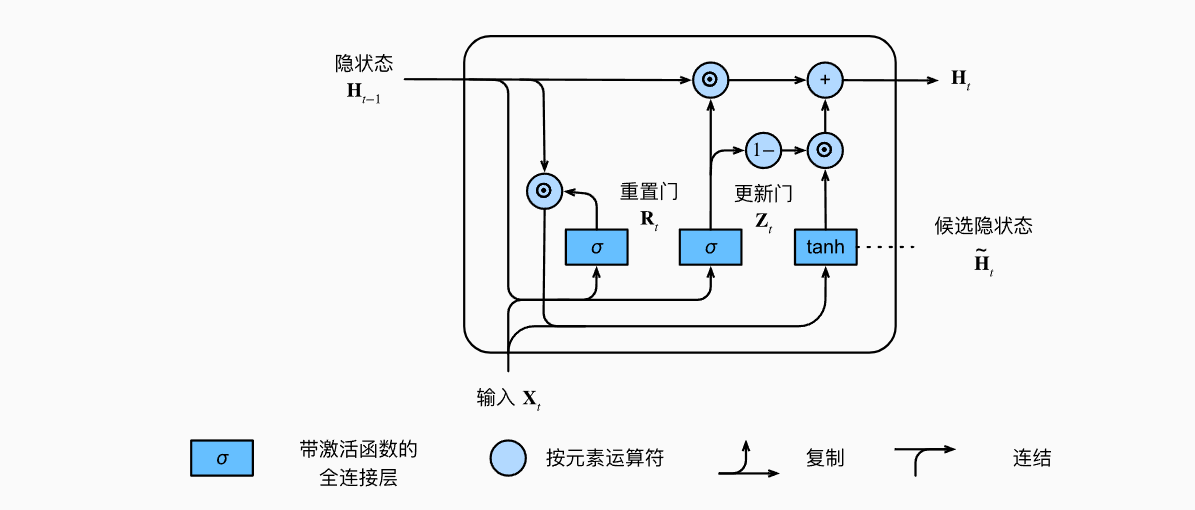
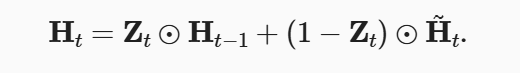

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

In [2]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three()  # 更新门参数
    W_xr, W_hr, b_r = three()  # 重置门参数
    W_xh, W_hh, b_h = three()  # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

In [3]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

In [4]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.tanh((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

time traveller                                                  
time traveller at at at at at at at at at at at at at at at at a
time travellere the the the the the the the the the the the the 
time traveller the the the the the the the the the the the the t
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time traveller the the the the the the the the the the the the t
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time traveller and the the the the the the the the the the the t
time travellere the the the the the the the the the the the the 
time traveller and the the the the the the the the the the the t
time traveller and the the the the the the the the the the the t
time traveller the the the the the the the the the the the the t
time traveller the the the the the the the the the the the the t
time traveller the the th

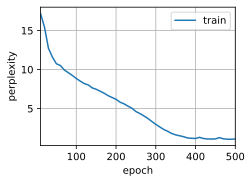

In [5]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params,
                            init_gru_state, gru)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

time traveller t t a t t a t t a t t a t t a t t a t t a t t a t
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time travellerererererererererererererererererererererererererer
time traveller the the the the the the the the the the the the t
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time travellere the the the the the the the the the the the the 
time traveller and the the the the the the the the the the the t
time travellere the there the there the there the there the ther
time traveller the the the the the the the the the the the the t
time traveller the the the the the the the the the the the the t
time traveller the there the there the there the there the there
time travellericensions and the there and the there and the ther
time traveller the the the the the the the the the the the the t
time traveller and the th

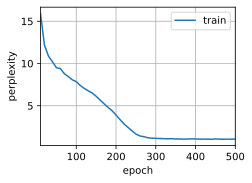

In [6]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs, num_hiddens)
model = d2l.RNNModel(gru_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)